## 03 — Neural Models

ทดสอบ neural baselines บน symbolic Thai notation — เป้าหมายเพื่อเทียบกับ shallow baselines
ใน notebook 02 (best = SVM bigram 0.685) และดูว่า sequence model + Thai-Beat-Counter
encoding เพิ่มค่าจริงไหม

## เป้าหมายของ notebook นี้

1. ใช้ token sequence โดยตรง (ไม่ใช่ aggregate features) เป็น input ของ neural model
2. เปรียบเทียบ 3 architectures: CNN, BiLSTM, Transformer (flat encoding)
3. ทดสอบ Thai-Beat-Counter encoding (factorized 4 facets) บน Transformer
4. Facet ablation V0 → V3 — facet ไหนช่วยจำแนกได้มากที่สุด
5. รายงานผลใน format เดียวกับ notebook 02 เพื่อเทียบได้ตรง

## Models ที่จะทดสอบ

| # | Model | Encoding |
|---|---|---|
| 9 | 1D CNN | flat token embedding |
| 10 | BiLSTM + attention | flat token embedding |
| 11 | Small Transformer | flat token embedding |
| 12 | Transformer + Thai-Beat-Counter (V3) | factorized 4 facets |
| 13 | Thai-Beat-Counter ablation | V0, V1, V2, V3 (4 variants) |

## โครงสร้าง

| Section | หัวข้อ |
|---|---|
| 1 | Setup |
| 2 | Tokenizer + vocab + PyTorch Dataset |
| 3 | Training loop (generic) |
| 4 | Model 9: 1D CNN |
| 5 | Model 10: BiLSTM + attention |
| 6 | Model 11: Small Transformer (flat) |
| 7 | Model 12: Transformer + Thai-Beat-Counter |
| 8 | Model 13: Facet ablation (V0 → V3) |
| 9 | Consolidated results — เทียบกับ shallow baselines |

## Output

- `results/tables/all_neural_runs.csv` — ทุก run (model × fold × seed)
- `results/tables/neural_summary.csv`
- `results/tables/facet_ablation.csv`
- `results/figures/neural_vs_shallow.png`
- `results/figures/facet_ablation.png`
- `results/figures/confusion_<best_neural>.png`

## 1. Setup

โหลด data + utils, ตั้ง device, สร้าง windows + labels เหมือน notebook 02

In [2]:
import sys
import os
import urllib.request
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/02_FindingInstrument')
else:
    PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Thai font
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
FONT_PATH = Path('/content/Sarabun-Regular.ttf') if IN_COLAB else Path.home() / 'Sarabun-Regular.ttf'
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont(str(FONT_PATH))
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

# Reload utils
import importlib
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_notes, build_windows, compute_features_dataframe,
    make_cv_splits, set_seed, save_fig, save_table,
    INSTRUMENTS, PIECES, FEATURE_COLS,
    LOW_MARK, HIGH_MARK, SUSTAIN, NOTE_BASES,
)

import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

set_seed(42)

# Load + prepare
df = load_notes()
df['section'] = df['section'].fillna('สาธุการ')
windows_df = build_windows(df, window_size=16, stride=8)
features_df = compute_features_dataframe(windows_df)

# Labels
inst_to_idx = {inst: i for i, inst in enumerate(INSTRUMENTS)}
windows_labels = features_df['instrument'].map(inst_to_idx).values

# สีสำหรับ instrument
inst_colors = {
    'ขลุ่ย-ปี่':   '#4477aa',
    'ฆ้องวงใหญ่': '#ee7733',
    'ซออู้':       '#228833',
    'ระนาดเอก':    '#cc3366',
}

print(f"\n✓ data: {len(df):,} bars")
print(f"✓ windows: {len(windows_df)} (size=16, stride=8)")
print(f"✓ labels: {windows_labels.shape}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
CUDA: 12.8

✓ data: 6,760 bars
✓ windows: 819 (size=16, stride=8)
✓ labels: (819,)


## 2. Tokenizer + vocab + PyTorch Dataset

ก่อน train neural model ต้องแปลง token strings เป็น integer IDs และ pack เป็น tensor

ขั้นตอน:
1. สร้าง vocabulary (token → int ID) ครอบคลุม 22 tokens + special tokens
2. แปลงทุก window's tokens เป็น list of IDs + padding
3. สร้าง PyTorch Dataset ที่ return (input_ids, length, label) ต่อ window
4. DataLoader ที่ batch ได้ทั้ง variable-length sequences

In [3]:
# สร้าง vocabulary — special tokens อยู่ ID ต่ำสุด, ตามด้วยจริง
PAD_ID = 0
UNK_ID = 1

# Token list ที่มีใน data — รวมตัวที่อาจไม่ปรากฏใน train fold หนึ่งแต่ปรากฏใน test fold
all_tokens_in_data = sorted(set(t for tokens in windows_df['tokens'] for t in tokens))
token_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
for tok in all_tokens_in_data:
    token_to_id[tok] = len(token_to_id)

id_to_token = {v: k for k, v in token_to_id.items()}
VOCAB_SIZE = len(token_to_id)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Special tokens: <PAD>={PAD_ID}, <UNK>={UNK_ID}")
print(f"Note tokens: {VOCAB_SIZE - 2}")
print(f"\nExample mapping:")
for tok, idx in list(token_to_id.items())[:10]:
    print(f"  {tok!r:>10s} → {idx}")

def encode_tokens(tokens, vocab=token_to_id):
    """แปลง list of token strings → list of int IDs"""
    return [vocab.get(t, UNK_ID) for t in tokens]

# Test
sample = windows_df.iloc[0]['tokens'][:10]
print(f"\nSample tokens: {sample}")
print(f"Encoded:       {encode_tokens(sample)}")

Vocabulary size: 24
Special tokens: <PAD>=0, <UNK>=1
Note tokens: 22

Example mapping:
     '<PAD>' → 0
     '<UNK>' → 1
         '-' → 2
         'ซ' → 3
        'ซฺ' → 4
        'ซํ' → 5
         'ด' → 6
        'ดฺ' → 7
        'ดํ' → 8
         'ท' → 9

Sample tokens: ['-', '-', '-', 'ม', '-', 'ซ', 'ซ', 'ซ', '-', '-']
Encoded:       [2, 2, 2, 15, 2, 3, 3, 3, 2, 2]


In [4]:
class NotationDataset(Dataset):
    """PyTorch Dataset สำหรับ windows — return (input_ids, length, label)"""

    def __init__(self, windows_subset, labels_subset, vocab=token_to_id):
        # Pre-encode ทุก window เป็น list of IDs (ยาวแปรผัน)
        self.sequences = [encode_tokens(toks, vocab) for toks in windows_subset['tokens']]
        self.labels = labels_subset

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        length = len(seq)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, length, label


def collate_pad(batch):
    """Pad sequences ใน batch ให้ความยาวเท่ากัน + return tensor + lengths + labels"""
    sequences, lengths, labels = zip(*batch)
    max_len = max(lengths)

    # Pad sequences ด้วย PAD_ID
    padded = torch.full((len(sequences), max_len), PAD_ID, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq

    lengths = torch.tensor(lengths, dtype=torch.long)
    labels = torch.stack(labels)
    return padded, lengths, labels


# Test
test_ds = NotationDataset(windows_df.iloc[:5], windows_labels[:5])
test_loader = DataLoader(test_ds, batch_size=3, collate_fn=collate_pad)

for batch_inputs, batch_lengths, batch_labels in test_loader:
    print(f"batch shape:   {batch_inputs.shape}  (batch_size, max_len)")
    print(f"lengths:       {batch_lengths.tolist()}")
    print(f"labels:        {batch_labels.tolist()}")
    print(f"sample row 0:  {batch_inputs[0][:15].tolist()}...")
    break

batch shape:   torch.Size([3, 69])  (batch_size, max_len)
lengths:       [69, 68, 64]
labels:        [0, 0, 0]
sample row 0:  [2, 2, 2, 15, 2, 3, 3, 3, 2, 2, 2, 21, 2, 3, 3]...


## 3. Training loop (generic)

สร้าง function `train_neural_model()` ที่:
1. รับ model factory + hyperparams
2. วน 6-fold leave-one-piece-out × 3 seeds = 18 runs
3. แต่ละ run: split train/test → train ด้วย early stopping → evaluate
4. คืน rows + confusion matrix ในรูปแบบเดียวกับ notebook 02

หลังจาก function นี้ ทุก model section จะแค่กำหนด architecture แล้วเรียก function นี้

In [5]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm

def train_one_fold(model, train_loader, val_loader, epochs=50, patience=10, lr=1e-3):
    """Train 1 model 1 fold ด้วย early stopping บน val loss"""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # Train
        model.train()
        for batch in train_loader:
            inputs, lengths, labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            logits = model(inputs, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                inputs, lengths, labels = [x.to(device) for x in batch]
                logits = model(inputs, lengths)
                val_losses.append(criterion(logits, labels).item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, epoch + 1


def predict(model, loader):
    """ทำนายทั้ง loader คืน y_pred + y_true เป็น numpy"""
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, lengths, labels = batch
            inputs, lengths = inputs.to(device), lengths.to(device)
            logits = model(inputs, lengths)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_pred.append(preds)
            all_true.append(labels.numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)


def evaluate_neural_model(
    model_factory, model_name,
    seeds=(42, 123, 2024), batch_size=32, epochs=50, patience=10, lr=1e-3,
):
    """รัน 6-fold × 3 seeds — model_factory คือ function ที่ return fresh model

    Returns: rows (list of dict), confusion (4x4)
    """
    rows = []
    confusion_total = np.zeros((4, 4), dtype=int)
    folds = list(make_cv_splits(features_df, group_col='piece'))
    total = len(seeds) * len(folds)

    with tqdm(total=total, desc=model_name) as pbar:
        for seed in seeds:
            set_seed(seed)
            for held_out, train_idx, test_idx in folds:
                # Build datasets
                train_ds = NotationDataset(windows_df.iloc[train_idx], windows_labels[train_idx])
                test_ds = NotationDataset(windows_df.iloc[test_idx], windows_labels[test_idx])
                train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                          collate_fn=collate_pad)
                test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                                         collate_fn=collate_pad)

                # Fresh model
                model = model_factory().to(device)
                model, epochs_used = train_one_fold(model, train_loader, test_loader,
                                                     epochs=epochs, patience=patience, lr=lr)

                # Evaluate
                y_pred, y_true = predict(model, test_loader)
                acc = accuracy_score(y_true, y_pred)
                f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
                f1_per = f1_score(y_true, y_pred, average=None, labels=range(4), zero_division=0)

                rows.append({
                    'model': model_name, 'seed': seed, 'held_out': held_out,
                    'accuracy': acc, 'macro_f1': f1_macro,
                    'f1_khlui': f1_per[0], 'f1_khong': f1_per[1],
                    'f1_so': f1_per[2], 'f1_ranat': f1_per[3],
                    'n_train': len(train_idx), 'n_test': len(test_idx),
                    'epochs_used': epochs_used,
                })
                confusion_total += confusion_matrix(y_true, y_pred, labels=range(4))

                pbar.update(1)
                pbar.set_postfix({'fold': held_out[:10], 'acc': f'{acc:.3f}', 'ep': epochs_used})

                # Cleanup GPU memory
                del model
                torch.cuda.empty_cache() if device.type == 'cuda' else None

    return rows, confusion_total


# Container สำหรับเก็บผล neural ทุก model (แยกจาก shallow ตอน notebook 02)
neural_rows = []
neural_confusion = {}

print("✓ training utilities พร้อม")

✓ training utilities พร้อม


## 4. Model 9: 1D CNN (Finding-Tori style)

Adapt Finding-Tori architecture จาก audio → symbolic
- Original: 4-layer 1D CNN (64/128/256/256) + context attention pool
- ของเรา: เปลี่ยน input จาก F0 contour 2-channel → token embedding 128-dim
- Pool ตัวสุดท้าย: mean pool (เริ่มง่าย ๆ ก่อน) → Linear classifier 4 class

In [6]:
class ThaiCNN(nn.Module):
    """1D CNN over token embeddings — Finding-Tori inspired"""

    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)

        # 4 layers — channel sizes 64/128/256/256 (Finding-Tori spec)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x, lengths=None):
        # x shape: (batch, seq_len)
        x = self.embedding(x)              # (B, L, embed_dim)
        x = x.transpose(1, 2)               # (B, embed_dim, L) — Conv1d expects channel-first

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        # x shape: (B, 256, L)

        # Mask out padding ก่อน mean pool
        if lengths is not None:
            mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
            mask = mask.unsqueeze(1).float()  # (B, 1, L)
            x = x * mask
            x = x.sum(dim=2) / mask.sum(dim=2)  # masked mean
        else:
            x = x.mean(dim=2)

        x = self.dropout(x)
        return self.classifier(x)  # (B, 4)


# Factory
def make_cnn():
    return ThaiCNN(embed_dim=128, dropout=0.3)

# Sanity check ก่อนรัน 18 folds
sample_model = make_cnn().to(device)
sample_inputs = torch.randint(0, VOCAB_SIZE, (4, 64)).to(device)
sample_lengths = torch.tensor([64, 64, 70, 64]).to(device)
sample_out = sample_model(sample_inputs, sample_lengths)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f"CNN output shape: {sample_out.shape}  (expect [4, 4])")
print(f"Total parameters: {n_params:,}")
del sample_model

# Train + evaluate 18 runs
rows, conf = evaluate_neural_model(make_cnn, '9_cnn',
                                    seeds=(42, 123, 2024),
                                    batch_size=32, epochs=50, patience=10, lr=1e-3)
neural_rows.extend(rows)
neural_confusion['9_cnn'] = conf

rdf = pd.DataFrame(rows)
print(f"\n9_cnn: acc {rdf['accuracy'].mean():.3f} ± {rdf['accuracy'].std():.3f}   "
      f"macro-F1 {rdf['macro_f1'].mean():.3f}   "
      f"avg epochs {rdf['epochs_used'].mean():.1f}")

CNN output shape: torch.Size([4, 4])  (expect [4, 4])
Total parameters: 350,276


9_cnn:   0%|          | 0/18 [00:00<?, ?it/s]


9_cnn: acc 0.698 ± 0.086   macro-F1 0.685   avg epochs 17.1


## 5. Model 10: BiLSTM + attention

BiLSTM กับ attention pool แทน mean pool — ดีกว่า CNN ตรงที่จับ long-range dependency
ในลำดับโน้ตได้ และ attention ทำให้ model focus ที่ token สำคัญ

In [9]:
class AttentionPool(nn.Module):
    """Self-attention pool — learn weighted sum ของ hidden states"""

    def __init__(self, dim):
        super().__init__()
        self.context = nn.Parameter(torch.randn(dim))

    def forward(self, x, mask=None):
        # x: (B, L, dim), mask: (B, L)
        scores = (x @ self.context) / (x.size(-1) ** 0.5)  # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = F.softmax(scores, dim=1)  # (B, L)
        return (x * weights.unsqueeze(-1)).sum(dim=1)  # (B, dim)


class ThaiBiLSTM(nn.Module):
    """BiLSTM + attention pool"""

    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
                 n_layers=2, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.attn = AttentionPool(hidden_dim * 2)  # bidirectional → 2x
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        # x: (B, L), lengths: (B,)
        x = self.embedding(x)  # (B, L, embed_dim)

        # Pack เพื่อให้ LSTM ข้าม pad tokens
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(),
                                                    batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        # out: (B, L, hidden_dim*2)

        # Attention pool with mask
        mask = (torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None])
        pooled = self.attn(out, mask=mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)


def make_bilstm():
    return ThaiBiLSTM(embed_dim=128, hidden_dim=128, n_layers=2, dropout=0.3)

# Sanity check — สร้าง sample ใหม่ที่ shape ครอบทุก lengths
sample_inputs_lstm = torch.randint(2, VOCAB_SIZE, (4, 70)).to(device)
sample_lengths_lstm = torch.tensor([70, 68, 64, 60]).to(device)
sample_model = make_bilstm().to(device)
sample_out = sample_model(sample_inputs_lstm, sample_lengths_lstm)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f"BiLSTM output shape: {sample_out.shape}  (expect [4, 4])")
print(f"Total parameters: {n_params:,}")
del sample_model
torch.cuda.empty_cache()

# Train
rows, conf = evaluate_neural_model(make_bilstm, '10_bilstm',
                                    seeds=(42, 123, 2024),
                                    batch_size=32, epochs=50, patience=10, lr=1e-3)
neural_rows.extend(rows)
neural_confusion['10_bilstm'] = conf

rdf = pd.DataFrame(rows)
print(f"\n10_bilstm: acc {rdf['accuracy'].mean():.3f} ± {rdf['accuracy'].std():.3f}   "
      f"macro-F1 {rdf['macro_f1'].mean():.3f}   "
      f"avg epochs {rdf['epochs_used'].mean():.1f}")

BiLSTM output shape: torch.Size([4, 4])  (expect [4, 4])
Total parameters: 663,812


10_bilstm:   0%|          | 0/18 [00:00<?, ?it/s]


10_bilstm: acc 0.698 ± 0.079   macro-F1 0.690   avg epochs 15.8


## 6. Model 11: Small Transformer (flat encoding)

Transformer encoder + context attention pool — เหมือน Finding-Tori ตัวที่ดีที่สุด
แต่ adapt มาใช้ token embedding แทน F0 contour

- 2 encoder layers (small เพราะ data น้อย)
- d_model=128, 4 heads, ff=256
- learnable positional embedding (สั้น, แค่ 80 positions พอ)
- Attention pool (เรียนรู้ token สำคัญในการตัดสิน)

In [12]:
class ThaiTransformer(nn.Module):
    """Small Transformer encoder + attention pool over token embedding"""

    def __init__(self, vocab_size=VOCAB_SIZE, d_model=128, n_heads=4,
                 n_layers=2, dim_ff=256, max_len=80, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, enable_nested_tensor=False)
        self.attn_pool = AttentionPool(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x, lengths):
        # x: (B, L)
        B, L = x.shape
        positions = torch.arange(L, device=x.device).clamp(max=self.max_len - 1)
        x = self.embedding(x) + self.pos_embedding(positions)[None, :, :]

        # Padding mask — True = ignore
        pad_mask = (torch.arange(L, device=x.device)[None, :] >= lengths[:, None])

        x = self.encoder(x, src_key_padding_mask=pad_mask)
        # x: (B, L, d_model)

        # Attention pool with token mask (~pad_mask = valid)
        pooled = self.attn_pool(x, mask=~pad_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)


def make_transformer_flat():
    return ThaiTransformer(d_model=128, n_heads=4, n_layers=2, dim_ff=256, dropout=0.3)

# Sanity check
sample_model = make_transformer_flat().to(device)
sample_out = sample_model(sample_inputs_lstm, sample_lengths_lstm)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f"Transformer output shape: {sample_out.shape}  (expect [4, 4])")
print(f"Total parameters: {n_params:,}")
del sample_model
torch.cuda.empty_cache()

# Train
rows, conf = evaluate_neural_model(make_transformer_flat, '11_transformer_flat',
                                    seeds=(42, 123, 2024),
                                    batch_size=32, epochs=50, patience=10, lr=1e-3)
neural_rows.extend(rows)
neural_confusion['11_transformer_flat'] = conf

rdf = pd.DataFrame(rows)
print(f"\n11_transformer_flat: acc {rdf['accuracy'].mean():.3f} ± {rdf['accuracy'].std():.3f}   "
      f"macro-F1 {rdf['macro_f1'].mean():.3f}   "
      f"avg epochs {rdf['epochs_used'].mean():.1f}")

Transformer output shape: torch.Size([4, 4])  (expect [4, 4])
Total parameters: 278,916


11_transformer_flat:   0%|          | 0/18 [00:00<?, ?it/s]


11_transformer_flat: acc 0.650 ± 0.095   macro-F1 0.635   avg epochs 15.3


## 7. Model 12: Transformer + Thai-Beat-Counter encoding

แทนที่ flat token embedding ด้วย **factorized embedding 4 facets**:

| Facet | Vocab size | ความหมาย |
|---|---|---|
| 1. **note_base** | 9 | ด/ร/ม/ฟ/ซ/ล/ท + sustain + pad |
| 2. **octave** | 4 | low / mid / high / none (for sustain) |
| 3. **is_lukabad** | 2 | bar ปกติ (4 tokens) vs ลูกสบัด (5+ tokens) |
| 4. **has_paren** | 2 | bar นี้เครื่องไม่เล่น |

แต่ละ facet มี embedding layer ของตัวเอง → sum → d_model
ทำให้ model **เรียนรู้ note pitch แยกจาก octave** แทนที่จะรวม `ด`, `ดํ`, `ดฺ` เป็น 3 tokens ไม่เกี่ยวกัน

### Hypothesis
- Pillar 1 §3.1 บอกว่า ลูกสบัด + octave + sustain เป็น signal เด่นต่างเครื่อง
- Factorized encoding ทำให้ model match กับ inductive bias ของดนตรีไทยได้ตรงกว่า
- → คาดว่า model 12 จะดีกว่า flat Transformer (model 11)

In [13]:
# Factorized features per token — สร้าง mapping จาก token → 4 facets
NOTE_BASE_TO_ID = {SUSTAIN: 0}  # sustain ID = 0
for i, b in enumerate(NOTE_BASES, start=1):
    NOTE_BASE_TO_ID[b] = i  # ด=1, ร=2, ม=3, ฟ=4, ซ=5, ล=6, ท=7
NOTE_BASE_VOCAB = len(NOTE_BASE_TO_ID) + 1  # +1 for PAD
NOTE_BASE_PAD = NOTE_BASE_VOCAB - 1

OCTAVE_TO_ID = {'sustain': 0, 'low': 1, 'mid': 2, 'high': 3}
OCTAVE_VOCAB = len(OCTAVE_TO_ID) + 1
OCTAVE_PAD = OCTAVE_VOCAB - 1

def encode_token_facets(token):
    """แปลง 1 token → (note_base_id, octave_id)"""
    if token == SUSTAIN:
        return NOTE_BASE_TO_ID[SUSTAIN], OCTAVE_TO_ID['sustain']
    base = token.replace(LOW_MARK, '').replace(HIGH_MARK, '')
    base_id = NOTE_BASE_TO_ID.get(base, 0)
    if LOW_MARK in token:
        oct_id = OCTAVE_TO_ID['low']
    elif HIGH_MARK in token:
        oct_id = OCTAVE_TO_ID['high']
    else:
        oct_id = OCTAVE_TO_ID['mid']
    return base_id, oct_id


# Build factorized features per window
# - note_base_seq, octave_seq: ยาวเท่า tokens
# - is_lukabad_seq, has_paren_seq: ยาวเท่า tokens (broadcast จาก bar-level)
def build_factorized_features(window_row, df_bars):
    """สร้าง 4 sequences ยาวเท่า tokens สำหรับ 1 window"""
    bars = df_bars[(df_bars['song_file'] == window_row['song_file']) &
                   (df_bars['bar_index'] >= window_row['start_bar']) &
                   (df_bars['bar_index'] <= window_row['end_bar'])]
    bars = bars.sort_values('bar_index')

    note_base_seq, octave_seq, lukabad_seq, paren_seq = [], [], [], []
    for _, bar in bars.iterrows():
        is_luka = 1 if bar['n_tokens'] >= 5 else 0
        has_par = 1 if bar['has_paren'] else 0
        for tok in bar['tokens']:
            nb, oc = encode_token_facets(tok)
            note_base_seq.append(nb)
            octave_seq.append(oc)
            lukabad_seq.append(is_luka)
            paren_seq.append(has_par)

    return note_base_seq, octave_seq, lukabad_seq, paren_seq


# Pre-compute สำหรับทุก window
print("Pre-computing factorized features for 819 windows...")
factorized = []
for _, w in tqdm(windows_df.iterrows(), total=len(windows_df), desc='factorize'):
    nb, oc, lu, pa = build_factorized_features(w, df)
    factorized.append({
        'note_base': nb, 'octave': oc, 'is_lukabad': lu, 'has_paren': pa,
    })

windows_df_facet = windows_df.copy()
windows_df_facet['note_base_seq'] = [f['note_base'] for f in factorized]
windows_df_facet['octave_seq'] = [f['octave'] for f in factorized]
windows_df_facet['is_lukabad_seq'] = [f['is_lukabad'] for f in factorized]
windows_df_facet['has_paren_seq'] = [f['has_paren'] for f in factorized]

# Test
print(f"\nSample window 0:")
print(f"  tokens:     {windows_df_facet.iloc[0]['tokens'][:10]}")
print(f"  note_base:  {windows_df_facet.iloc[0]['note_base_seq'][:10]}")
print(f"  octave:     {windows_df_facet.iloc[0]['octave_seq'][:10]}")
print(f"  is_lukabad: {windows_df_facet.iloc[0]['is_lukabad_seq'][:10]}")
print(f"  has_paren:  {windows_df_facet.iloc[0]['has_paren_seq'][:10]}")
print(f"\nVocab sizes:")
print(f"  note_base: {NOTE_BASE_VOCAB} (incl PAD)")
print(f"  octave:    {OCTAVE_VOCAB} (incl PAD)")
print(f"  is_lukabad: 2 (binary)")
print(f"  has_paren:  2 (binary)")

Pre-computing factorized features for 819 windows...


factorize:   0%|          | 0/819 [00:00<?, ?it/s]


Sample window 0:
  tokens:     ['-', '-', '-', 'ม', '-', 'ซ', 'ซ', 'ซ', '-', '-']
  note_base:  [0, 0, 0, 3, 0, 5, 5, 5, 0, 0]
  octave:     [0, 0, 0, 2, 0, 2, 2, 2, 0, 0]
  is_lukabad: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  has_paren:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Vocab sizes:
  note_base: 9 (incl PAD)
  octave:    5 (incl PAD)
  is_lukabad: 2 (binary)
  has_paren:  2 (binary)


In [14]:
class FacetDataset(Dataset):
    """Dataset ที่ return 4 facet sequences + length + label"""

    def __init__(self, windows_subset, labels_subset, use_facets=('note_base', 'octave',
                                                                   'is_lukabad', 'has_paren')):
        self.note_base = [list(s) for s in windows_subset['note_base_seq']]
        self.octave = [list(s) for s in windows_subset['octave_seq']]
        self.lukabad = [list(s) for s in windows_subset['is_lukabad_seq']]
        self.paren = [list(s) for s in windows_subset['has_paren_seq']]
        self.labels = labels_subset
        self.use_facets = use_facets

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        length = len(self.note_base[idx])
        return {
            'note_base':  torch.tensor(self.note_base[idx], dtype=torch.long),
            'octave':     torch.tensor(self.octave[idx], dtype=torch.long),
            'is_lukabad': torch.tensor(self.lukabad[idx], dtype=torch.long),
            'has_paren':  torch.tensor(self.paren[idx], dtype=torch.long),
            'length':     length,
            'label':      torch.tensor(self.labels[idx], dtype=torch.long),
        }


def collate_facet(batch):
    max_len = max(item['length'] for item in batch)
    B = len(batch)

    out = {}
    for facet, pad_id in [('note_base', NOTE_BASE_PAD), ('octave', OCTAVE_PAD),
                          ('is_lukabad', 0), ('has_paren', 0)]:
        padded = torch.full((B, max_len), pad_id, dtype=torch.long)
        for i, item in enumerate(batch):
            seq = item[facet]
            padded[i, :len(seq)] = seq
        out[facet] = padded

    out['lengths'] = torch.tensor([item['length'] for item in batch], dtype=torch.long)
    out['labels'] = torch.stack([item['label'] for item in batch])
    return out


class ThaiBeatCounterTransformer(nn.Module):
    """Transformer with factorized 4-facet embedding"""

    def __init__(self, d_model=128, n_heads=4, n_layers=2, dim_ff=256,
                 max_len=80, n_classes=4, dropout=0.3,
                 use_facets=('note_base', 'octave', 'is_lukabad', 'has_paren')):
        super().__init__()
        self.use_facets = use_facets

        # Embedding per facet — แต่ละตัว project ไปยัง d_model
        self.embeddings = nn.ModuleDict()
        if 'note_base' in use_facets:
            self.embeddings['note_base'] = nn.Embedding(NOTE_BASE_VOCAB, d_model,
                                                         padding_idx=NOTE_BASE_PAD)
        if 'octave' in use_facets:
            self.embeddings['octave'] = nn.Embedding(OCTAVE_VOCAB, d_model,
                                                      padding_idx=OCTAVE_PAD)
        if 'is_lukabad' in use_facets:
            self.embeddings['is_lukabad'] = nn.Embedding(2, d_model)
        if 'has_paren' in use_facets:
            self.embeddings['has_paren'] = nn.Embedding(2, d_model)

        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
        self.attn_pool = AttentionPool(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, batch):
        lengths = batch['lengths']
        device_ = lengths.device

        # Sum embeddings ของทุก facet ที่ใช้
        first_facet = list(self.use_facets)[0]
        B, L = batch[first_facet].shape

        x = torch.zeros(B, L, self.embeddings[first_facet].embedding_dim, device=device_)
        for facet in self.use_facets:
            x = x + self.embeddings[facet](batch[facet])

        # Positional
        positions = torch.arange(L, device=device_).clamp(max=self.max_len - 1)
        x = x + self.pos_embedding(positions)[None, :, :]

        # Padding mask
        pad_mask = (torch.arange(L, device=device_)[None, :] >= lengths[:, None])

        x = self.encoder(x, src_key_padding_mask=pad_mask)
        pooled = self.attn_pool(x, mask=~pad_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)


# Sanity check
def make_tbc_full():
    return ThaiBeatCounterTransformer(use_facets=('note_base', 'octave',
                                                    'is_lukabad', 'has_paren'))

sample_ds = FacetDataset(windows_df_facet.iloc[:4], windows_labels[:4])
sample_loader = DataLoader(sample_ds, batch_size=4, collate_fn=collate_facet)
sample_batch = next(iter(sample_loader))
sample_batch = {k: v.to(device) for k, v in sample_batch.items()}

sample_model = make_tbc_full().to(device)
sample_out = sample_model(sample_batch)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f"TBC Transformer output shape: {sample_out.shape}  (expect [4, 4])")
print(f"Total parameters: {n_params:,}")
del sample_model
torch.cuda.empty_cache()

TBC Transformer output shape: torch.Size([4, 4])  (expect [4, 4])
Total parameters: 278,148


In [15]:
def evaluate_facet_model(
    model_factory, model_name,
    seeds=(42, 123, 2024), batch_size=32, epochs=50, patience=10, lr=1e-3,
):
    """รัน 6-fold × 3 seeds สำหรับ FacetDataset-based model"""
    rows = []
    confusion_total = np.zeros((4, 4), dtype=int)
    folds = list(make_cv_splits(features_df, group_col='piece'))
    total = len(seeds) * len(folds)

    with tqdm(total=total, desc=model_name) as pbar:
        for seed in seeds:
            set_seed(seed)
            for held_out, train_idx, test_idx in folds:
                train_ds = FacetDataset(windows_df_facet.iloc[train_idx],
                                         windows_labels[train_idx])
                test_ds = FacetDataset(windows_df_facet.iloc[test_idx],
                                        windows_labels[test_idx])
                train_loader = DataLoader(train_ds, batch_size=batch_size,
                                           shuffle=True, collate_fn=collate_facet)
                test_loader = DataLoader(test_ds, batch_size=batch_size,
                                          shuffle=False, collate_fn=collate_facet)

                model = model_factory().to(device)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
                criterion = nn.CrossEntropyLoss()

                best_val = float('inf')
                best_state = None
                no_improve = 0
                epochs_used = epochs

                for epoch in range(epochs):
                    model.train()
                    for batch in train_loader:
                        batch = {k: v.to(device) for k, v in batch.items()}
                        optimizer.zero_grad()
                        logits = model(batch)
                        loss = criterion(logits, batch['labels'])
                        loss.backward()
                        optimizer.step()

                    model.eval()
                    val_losses = []
                    with torch.no_grad():
                        for batch in test_loader:
                            batch = {k: v.to(device) for k, v in batch.items()}
                            logits = model(batch)
                            val_losses.append(criterion(logits, batch['labels']).item())
                    val_loss = np.mean(val_losses)

                    if val_loss < best_val:
                        best_val = val_loss
                        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                        no_improve = 0
                    else:
                        no_improve += 1
                        if no_improve >= patience:
                            epochs_used = epoch + 1
                            break

                if best_state is not None:
                    model.load_state_dict(best_state)

                # Predict
                model.eval()
                all_pred, all_true = [], []
                with torch.no_grad():
                    for batch in test_loader:
                        batch_dev = {k: v.to(device) for k, v in batch.items()}
                        logits = model(batch_dev)
                        all_pred.append(logits.argmax(dim=1).cpu().numpy())
                        all_true.append(batch['labels'].numpy())
                y_pred = np.concatenate(all_pred)
                y_true = np.concatenate(all_true)

                acc = accuracy_score(y_true, y_pred)
                f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
                f1_per = f1_score(y_true, y_pred, average=None, labels=range(4), zero_division=0)

                rows.append({
                    'model': model_name, 'seed': seed, 'held_out': held_out,
                    'accuracy': acc, 'macro_f1': f1_macro,
                    'f1_khlui': f1_per[0], 'f1_khong': f1_per[1],
                    'f1_so': f1_per[2], 'f1_ranat': f1_per[3],
                    'n_train': len(train_idx), 'n_test': len(test_idx),
                    'epochs_used': epochs_used,
                })
                confusion_total += confusion_matrix(y_true, y_pred, labels=range(4))

                pbar.update(1)
                pbar.set_postfix({'fold': held_out[:10], 'acc': f'{acc:.3f}', 'ep': epochs_used})

                del model
                torch.cuda.empty_cache() if device.type == 'cuda' else None

    return rows, confusion_total


# Train model 12 — Transformer + all 4 facets
rows, conf = evaluate_facet_model(make_tbc_full, '12_tbc_full',
                                    seeds=(42, 123, 2024),
                                    batch_size=32, epochs=50, patience=10, lr=1e-3)
neural_rows.extend(rows)
neural_confusion['12_tbc_full'] = conf

rdf = pd.DataFrame(rows)
print(f"\n12_tbc_full: acc {rdf['accuracy'].mean():.3f} ± {rdf['accuracy'].std():.3f}   "
      f"macro-F1 {rdf['macro_f1'].mean():.3f}   "
      f"avg epochs {rdf['epochs_used'].mean():.1f}")

12_tbc_full:   0%|          | 0/18 [00:00<?, ?it/s]


12_tbc_full: acc 0.662 ± 0.097   macro-F1 0.638   avg epochs 15.2


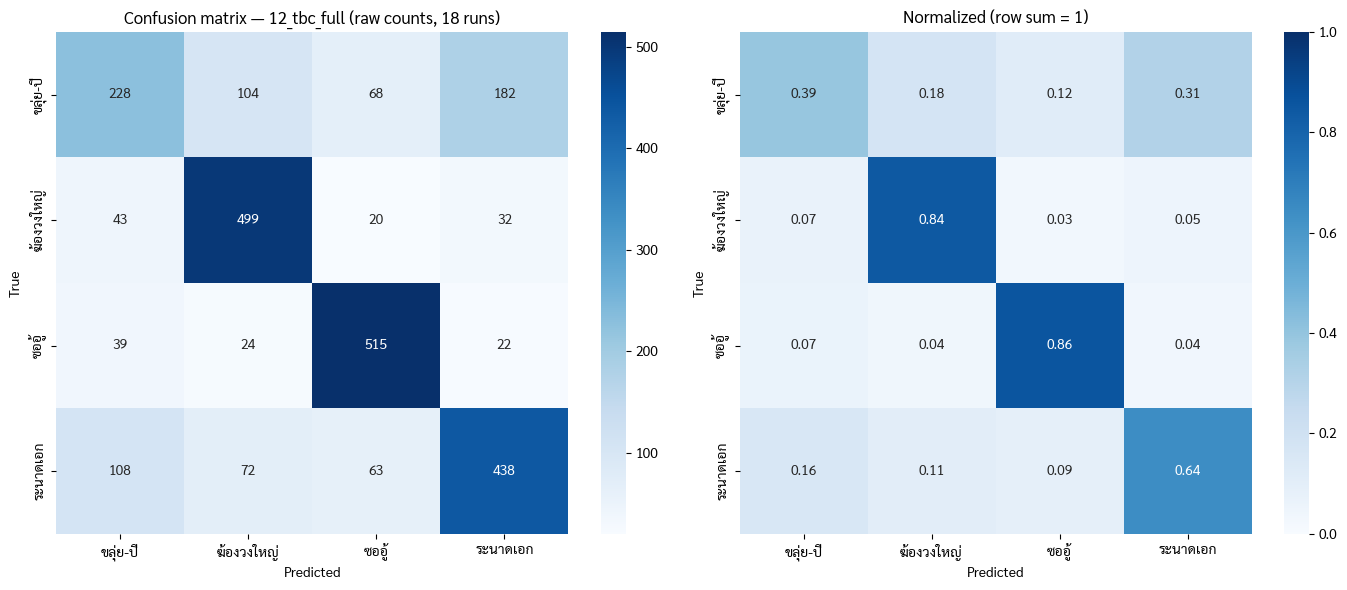


Recall per class (4 neural models in this notebook):


,ขลุ่ย-ปี่,ฆ้องวงใหญ่,ซออู้,ระนาดเอก,macro_recall
9_cnn,0.481,0.842,0.863,0.687,0.718
10_bilstm,0.534,0.833,0.808,0.659,0.708
11_transformer_flat,0.467,0.785,0.858,0.602,0.678
12_tbc_full,0.392,0.840,0.858,0.643,0.683



ความต่าง (12_tbc_full − 11_transformer_flat) per class:


,Δ recall
ขลุ่ย-ปี่,-0.075
ฆ้องวงใหญ่,0.055
ซออู้,0.000
ระนาดเอก,0.041
macro_recall,0.005


In [17]:
# Confusion matrix ของ 12_tbc_full
conf = neural_confusion['12_tbc_full']
conf_norm = conf / conf.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[0])
axes[0].set_title('Confusion matrix — 12_tbc_full (raw counts, 18 runs)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[1])
axes[1].set_title('Normalized (row sum = 1)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
save_fig('confusion_12_tbc_full')
plt.show()

# Recall per class — เทียบเฉพาะ 4 neural models
print("\nRecall per class (4 neural models in this notebook):")

neural_models = ['9_cnn', '10_bilstm', '11_transformer_flat', '12_tbc_full']
recall_table = {}

for m in neural_models:
    c = neural_confusion[m]
    rec = c.diagonal() / c.sum(axis=1)
    recall_table[m] = dict(zip(INSTRUMENTS, rec.round(3)))

recall_df = pd.DataFrame(recall_table).T
recall_df['macro_recall'] = recall_df.mean(axis=1).round(3)
display(recall_df)

# ความต่าง 12_tbc_full - 11_transformer_flat — facet ช่วย class ไหน
print("\nความต่าง (12_tbc_full − 11_transformer_flat) per class:")
delta = (recall_df.loc['12_tbc_full'] - recall_df.loc['11_transformer_flat']).round(3)
display(delta.to_frame('Δ recall'))

## 8. Model 13: Facet ablation (V0 → V3)

ตอบคำถาม: facet ไหนใน Thai-Beat-Counter ช่วยจริง?

| Variant | Facets | สมมุติฐาน |
|---|---|---|
| **V0** | note_base | minimum baseline — เหมือน Transformer flat แต่แค่ note ไม่มี octave |
| **V1** | + octave | ควรช่วย — octave เป็น signature ของ ขลุ่ย-ปี่ (high) vs ฆ้องวงใหญ่ (low) |
| **V2** | + is_lukabad | ควรช่วย — ฆ้องวงใหญ่ ลูกสบัด เด่นที่สุด |
| **V3** | + has_paren | ขนาด effect เล็ก — paren ratio ใกล้กันทุกเครื่อง (0.6-0.9%) |

จาก Pillar 1 §8.3 has_paren **ไม่ใช่ trivial cue** — คาดว่า V3 ≈ V2 (improvement น้อย)

In [18]:
def make_tbc(facets):
    """Factory function ที่รับ facets list"""
    return lambda: ThaiBeatCounterTransformer(use_facets=facets)

variants = {
    '13_tbc_V0': ('note_base',),
    '13_tbc_V1': ('note_base', 'octave'),
    '13_tbc_V2': ('note_base', 'octave', 'is_lukabad'),
    # V3 = 12_tbc_full (มีแล้ว — ไม่รันใหม่)
}

for variant_name, facets in variants.items():
    rows, conf = evaluate_facet_model(make_tbc(facets), variant_name,
                                       seeds=(42, 123, 2024),
                                       batch_size=32, epochs=50, patience=10, lr=1e-3)
    neural_rows.extend(rows)
    neural_confusion[variant_name] = conf
    rdf = pd.DataFrame(rows)
    print(f"{variant_name}: acc {rdf['accuracy'].mean():.3f} ± {rdf['accuracy'].std():.3f}   "
          f"macro-F1 {rdf['macro_f1'].mean():.3f}   "
          f"avg epochs {rdf['epochs_used'].mean():.1f}")

print(f"\nรวม neural runs: {len(neural_rows)}")

13_tbc_V0:   0%|          | 0/18 [00:00<?, ?it/s]

13_tbc_V0: acc 0.482 ± 0.102   macro-F1 0.450   avg epochs 15.2


13_tbc_V1:   0%|          | 0/18 [00:00<?, ?it/s]

13_tbc_V1: acc 0.634 ± 0.090   macro-F1 0.617   avg epochs 15.2


13_tbc_V2:   0%|          | 0/18 [00:00<?, ?it/s]

13_tbc_V2: acc 0.652 ± 0.080   macro-F1 0.633   avg epochs 14.7

รวม neural runs: 126


## 9. Consolidated results

สรุปทุก neural model + เทียบกับ shallow baselines จาก notebook 02
ใช้เพื่อ:
- Save CSV ที่ Pillar 4 (interpretability) จะใช้
- ภาพ ranking สำหรับ presentation
- ablation plot ของ TBC variants
- per-class F1 heatmap

In [19]:
# Save neural runs
neural_df = pd.DataFrame(neural_rows)
save_table(neural_df, 'all_neural_runs')

# Neural summary
neural_summary = (neural_df.groupby('model')
                  .agg(acc_mean=('accuracy', 'mean'),
                       acc_std=('accuracy', 'std'),
                       f1_mean=('macro_f1', 'mean'),
                       f1_std=('macro_f1', 'std'),
                       avg_epochs=('epochs_used', 'mean'),
                       n_runs=('accuracy', 'count'))
                  .round(4)
                  .sort_values('acc_mean', ascending=False))
display(neural_summary)
save_table(neural_summary.reset_index(), 'neural_summary')

# Load shallow summary จาก notebook 02 — เพื่อรวม table
shallow_summary = pd.read_csv(PROJECT_ROOT / 'results/tables/baseline_summary.csv')
shallow_summary = shallow_summary.set_index('model').round(4)
print(f"\n✓ loaded shallow summary จาก notebook 02 ({len(shallow_summary)} models)")
display(shallow_summary)

,acc_mean,acc_std,f1_mean,f1_std,avg_epochs,n_runs
model,,,,,,
9_cnn,0.6980,0.0856,0.6845,0.0809,17.0556,18
10_bilstm,0.6977,0.0788,0.6896,0.0695,15.7778,18
12_tbc_full,0.6621,0.0967,0.6384,0.0988,15.1667,18
13_tbc_V2,0.6516,0.0803,0.6329,0.0679,14.7222,18
11_transformer_flat,0.6499,0.0953,0.6353,0.0886,15.2778,18
13_tbc_V1,0.6337,0.0901,0.6167,0.0872,15.1667,18
13_tbc_V0,0.4818,0.1025,0.4500,0.1020,15.1667,18



✓ loaded shallow summary จาก notebook 02 (9 models)


,acc_mean,acc_std,f1_mean,f1_std,n_runs
model,,,,,
6_svm_bigram,0.6848,0.0848,0.6734,0.0824,18
7_svm_trigram,0.6824,0.0871,0.6703,0.0835,18
8_xgb_combined,0.6480,0.1023,0.6296,0.0870,18
5_svm_unigram,0.6200,0.1217,0.6013,0.1197,18
2_lr_handcrafted,0.6106,0.0647,0.5798,0.0645,18
4_nb_unigram,0.6043,0.1281,0.5812,0.1386,18
3_rf_handcrafted,0.5478,0.0747,0.5271,0.0669,18
1_majority,0.2790,0.0499,0.1085,0.0146,18
0_random,0.2467,0.0279,0.2441,0.0263,18


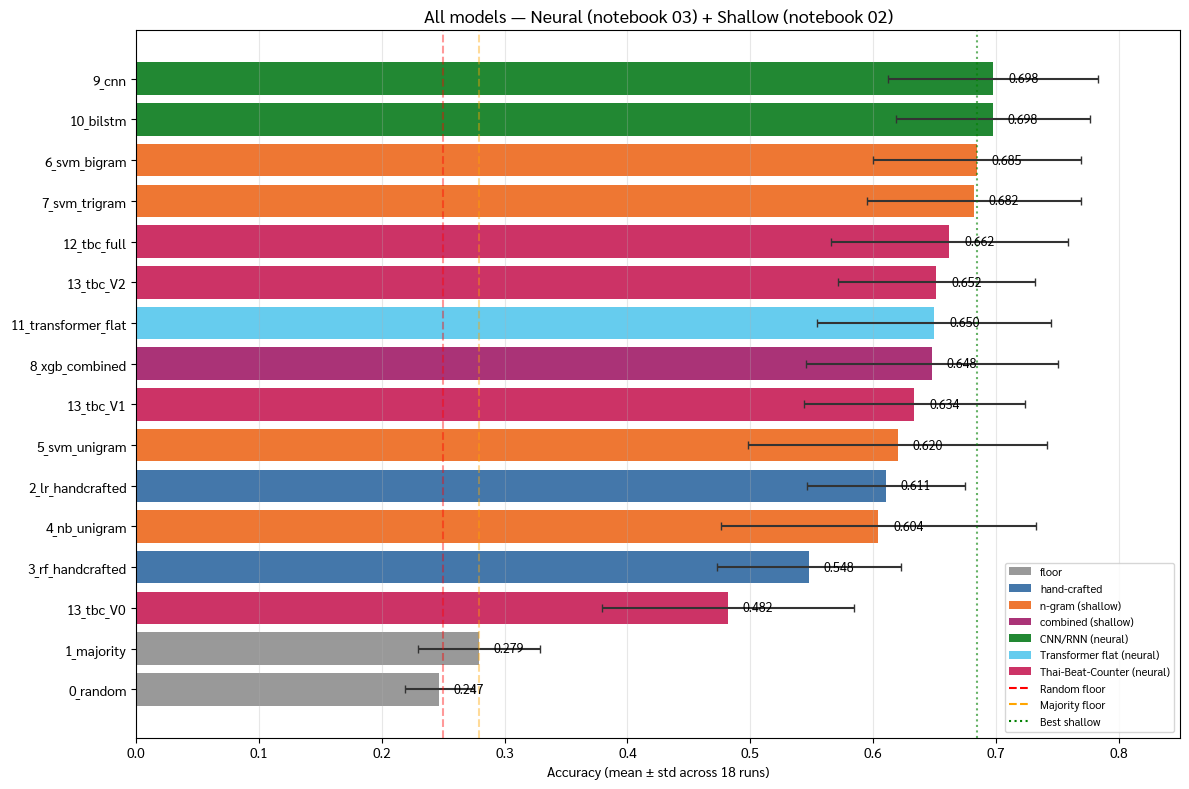

✓ saved → all_models_accuracy.png + all_models_summary.csv


In [20]:
# รวม neural + shallow summary เป็น 1 ตาราง
combined = pd.concat([
    neural_summary[['acc_mean', 'acc_std', 'f1_mean', 'f1_std', 'n_runs']],
    shallow_summary
]).sort_values('acc_mean', ascending=True)

# Categorize model สำหรับสีแยก
def model_category(name):
    if name in ('0_random', '1_majority'):          return 'floor'
    if 'handcrafted' in name:                       return 'hand-crafted'
    if 'nb_' in name or 'svm_' in name:             return 'n-gram (shallow)'
    if 'xgb' in name:                               return 'combined (shallow)'
    if name in ('9_cnn', '10_bilstm'):              return 'CNN/RNN (neural)'
    if name == '11_transformer_flat':               return 'Transformer flat (neural)'
    if name.startswith('12_tbc') or name.startswith('13_tbc'): return 'Thai-Beat-Counter (neural)'
    return 'other'

cat_colors = {
    'floor':                    '#999999',
    'hand-crafted':             '#4477aa',
    'n-gram (shallow)':         '#ee7733',
    'combined (shallow)':       '#aa3377',
    'CNN/RNN (neural)':         '#228833',
    'Transformer flat (neural)':'#66ccee',
    'Thai-Beat-Counter (neural)':'#cc3366',
}
combined['category'] = combined.index.map(model_category)
colors = [cat_colors[c] for c in combined['category']]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(combined.index, combined['acc_mean'],
               xerr=combined['acc_std'], color=colors,
               error_kw={'ecolor': '#333', 'capsize': 3})

# Annotate
for bar, acc in zip(bars, combined['acc_mean']):
    ax.text(acc + 0.012, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=9)

# Reference lines
ax.axvline(0.25, color='red', linestyle='--', alpha=0.4, label='Random floor')
ax.axvline(0.279, color='orange', linestyle='--', alpha=0.4, label='Majority floor')
ax.axvline(0.685, color='green', linestyle=':', alpha=0.6, label='Best shallow (SVM bigram)')

ax.set_xlabel('Accuracy (mean ± std across 18 runs)')
ax.set_title('All models — Neural (notebook 03) + Shallow (notebook 02)', fontsize=13)
ax.set_xlim(0, 0.85)

# Custom legend สำหรับ categories
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
legend_handles += [
    plt.Line2D([0], [0], color='red', linestyle='--', label='Random floor'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='Majority floor'),
    plt.Line2D([0], [0], color='green', linestyle=':', label='Best shallow'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig('all_models_accuracy')
plt.show()

save_table(combined.reset_index(), 'all_models_summary')
print("✓ saved → all_models_accuracy.png + all_models_summary.csv")

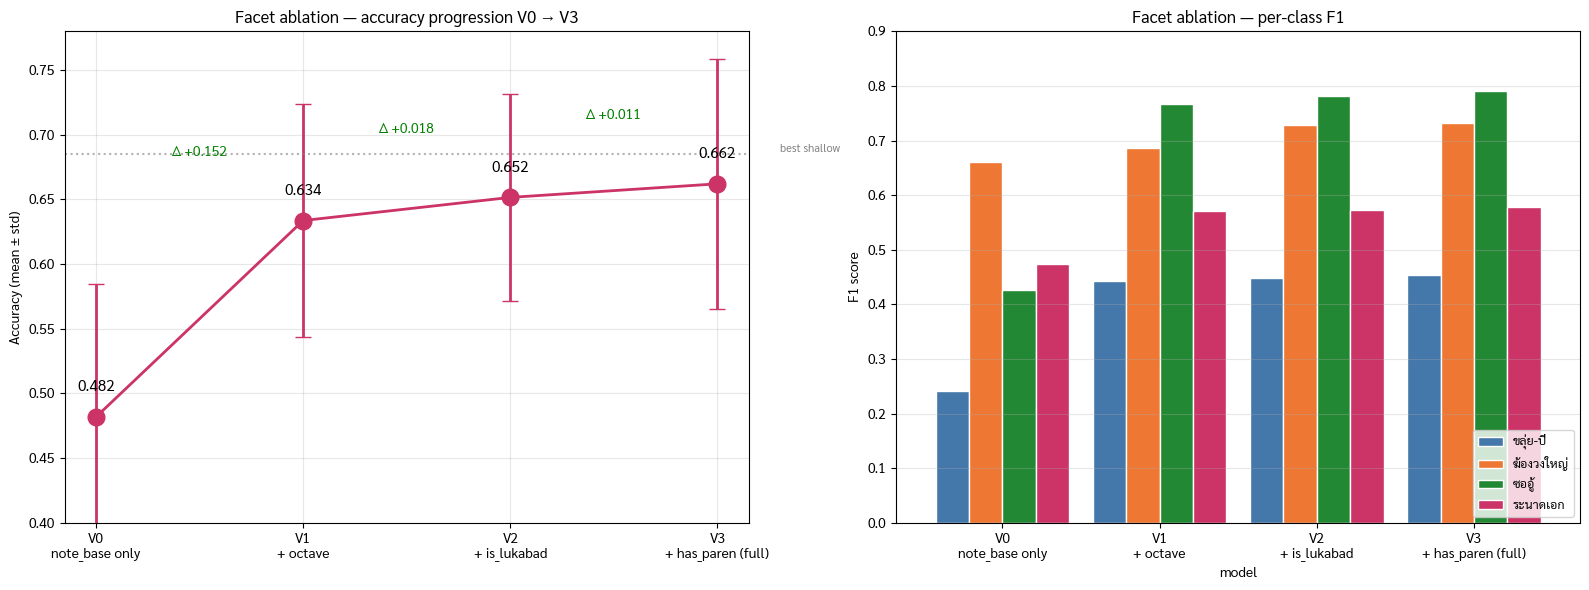

,variant,facet_added,acc_mean,acc_std,delta_from_prev
0,V0\nnote_base only,note_base,0.4818,0.1025,0.0000
1,V1\n+ octave,+ octave,0.6337,0.0901,0.1519
2,V2\n+ is_lukabad,+ is_lukabad,0.6516,0.0803,0.0179
3,V3\n+ has_paren (full),+ has_paren,0.6621,0.0967,0.0105



✓ saved → facet_ablation.png + facet_ablation.csv


In [21]:
# Ablation chain: V0 → V1 → V2 → V3 (= 12_tbc_full)
# Plot 2 panels: accuracy line + per-class F1 bars
ablation_models = ['13_tbc_V0', '13_tbc_V1', '13_tbc_V2', '12_tbc_full']
ablation_labels = [
    'V0\nnote_base only',
    'V1\n+ octave',
    'V2\n+ is_lukabad',
    'V3\n+ has_paren (full)',
]
added_facets = ['note_base', '+ octave', '+ is_lukabad', '+ has_paren']

# Aggregate stats
ablation_acc = neural_summary.loc[ablation_models, 'acc_mean'].values
ablation_std = neural_summary.loc[ablation_models, 'acc_std'].values
ablation_deltas = np.diff(ablation_acc, prepend=ablation_acc[0])

# Per-class F1
ablation_f1 = (neural_df[neural_df['model'].isin(ablation_models)]
                .groupby('model')[['f1_khlui', 'f1_khong', 'f1_so', 'f1_ranat']]
                .mean()
                .loc[ablation_models])
ablation_f1.columns = ['ขลุ่ย-ปี่', 'ฆ้องวงใหญ่', 'ซออู้', 'ระนาดเอก']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: accuracy line with delta annotations
ax = axes[0]
ax.errorbar(range(4), ablation_acc, yerr=ablation_std, marker='o', markersize=12,
            linewidth=2, capsize=6, color='#cc3366')
ax.set_xticks(range(4))
ax.set_xticklabels(ablation_labels, fontsize=10)
ax.set_ylabel('Accuracy (mean ± std)')
ax.set_title('Facet ablation — accuracy progression V0 → V3', fontsize=12)
ax.set_ylim(0.4, 0.78)
ax.grid(alpha=0.3)

# Annotate ค่า + delta
for i, (acc, delta) in enumerate(zip(ablation_acc, ablation_deltas)):
    ax.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
    if i > 0:
        sign = '+' if delta >= 0 else ''
        color = 'green' if delta > 0.01 else ('orange' if delta > 0 else 'red')
        ax.text(i - 0.5, max(ablation_acc[i-1], acc) + 0.05,
                f'Δ {sign}{delta:.3f}', ha='center', fontsize=10,
                color=color, fontweight='bold')

# Reference line — best shallow
ax.axhline(0.685, color='gray', linestyle=':', alpha=0.6)
ax.text(3.3, 0.687, 'best shallow', fontsize=8, color='gray')

# Panel 2: Per-class F1
ax = axes[1]
ablation_f1.plot(kind='bar', ax=ax, color=[inst_colors[c] for c in ablation_f1.columns],
                  edgecolor='white', width=0.85)
ax.set_xticklabels(ablation_labels, rotation=0, fontsize=10)
ax.set_ylabel('F1 score')
ax.set_title('Facet ablation — per-class F1', fontsize=12)
ax.set_ylim(0, 0.9)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('facet_ablation')
plt.show()

# Save ablation table
ablation_table = pd.DataFrame({
    'variant': ablation_labels,
    'facet_added': added_facets,
    'acc_mean': ablation_acc.round(4),
    'acc_std': ablation_std.round(4),
    'delta_from_prev': ablation_deltas.round(4),
})
display(ablation_table)
save_table(ablation_table, 'facet_ablation')
print("\n✓ saved → facet_ablation.png + facet_ablation.csv")

,ขลุ่ย-ปี่,ฆ้องวงใหญ่,ซออู้,ระนาดเอก,macro
model,,,,,
10_bilstm,0.569,0.747,0.799,0.643,0.690
9_cnn,0.553,0.763,0.772,0.649,0.685
12_tbc_full,0.454,0.731,0.790,0.578,0.638
11_transformer_flat,0.488,0.701,0.794,0.558,0.635
13_tbc_V2,0.448,0.729,0.781,0.573,0.633
13_tbc_V1,0.443,0.686,0.768,0.570,0.617
13_tbc_V0,0.241,0.660,0.426,0.473,0.450


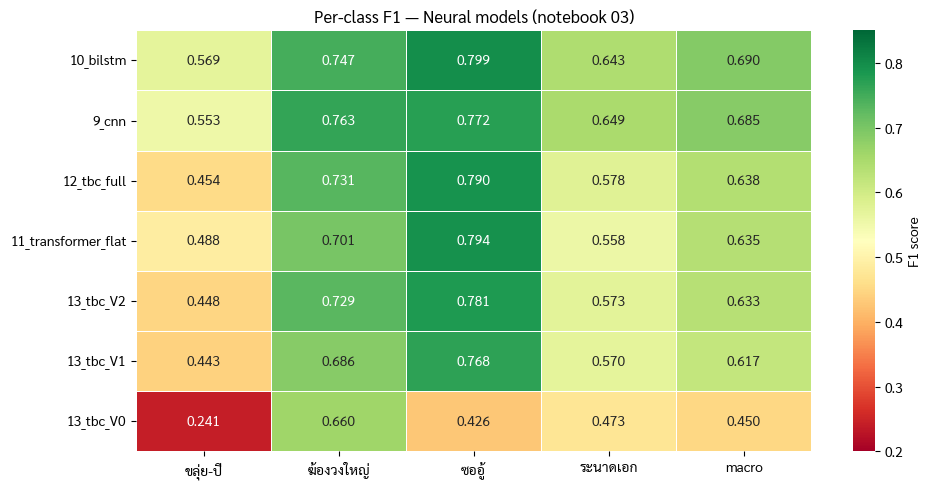

✓ saved


In [22]:
# Per-class F1 heatmap — รวมทุก model
all_per_class = neural_df.groupby('model')[['f1_khlui', 'f1_khong', 'f1_so', 'f1_ranat', 'macro_f1']].mean()
all_per_class.columns = ['ขลุ่ย-ปี่', 'ฆ้องวงใหญ่', 'ซออู้', 'ระนาดเอก', 'macro']
all_per_class = all_per_class.round(3).sort_values('macro', ascending=False)

display(all_per_class)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(all_per_class, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.2, vmax=0.85, cbar_kws={'label': 'F1 score'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Per-class F1 — Neural models (notebook 03)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
save_fig('per_class_f1_neural')
plt.show()
save_table(all_per_class.reset_index(), 'per_class_f1_neural')
print("✓ saved")

BEST NEURAL MODELS — tied ระหว่าง 9_cnn และ 10_bilstm


,acc_mean,acc_std,f1_mean,f1_std,avg_epochs
model,,,,,
9_cnn,0.6980,0.0856,0.6845,0.0809,17.0556
10_bilstm,0.6977,0.0788,0.6896,0.0695,15.7778



หมายเหตุ: dataset นี้ balanced (ratio 1.17) — accuracy และ macro-F1
ให้ผลใกล้กันมาก ตัวเลขทั้งคู่ใกล้กันจน 'best' ตัดสินยาก:

  - Accuracy:   9_cnn   ดีกว่าเล็กน้อย (+0.0003)
  - Macro-F1:   10_bilstm ดีกว่า (+0.005) — สะท้อน per-class fairness
  - Std:        10_bilstm เสถียรกว่า (0.079 vs 0.086)
  - Params:     9_cnn เล็กกว่า (350K vs 663K)
  - Train time: 9_cnn เร็วกว่า (39s vs 104s)

สรุป: 2 model ทำงานเทียบเท่ากัน — เลือกตาม trade-off ที่ project ต้องการ
ภาพข้างล่างแสดงทั้งคู่เพื่อเปรียบเทียบ confusion pattern


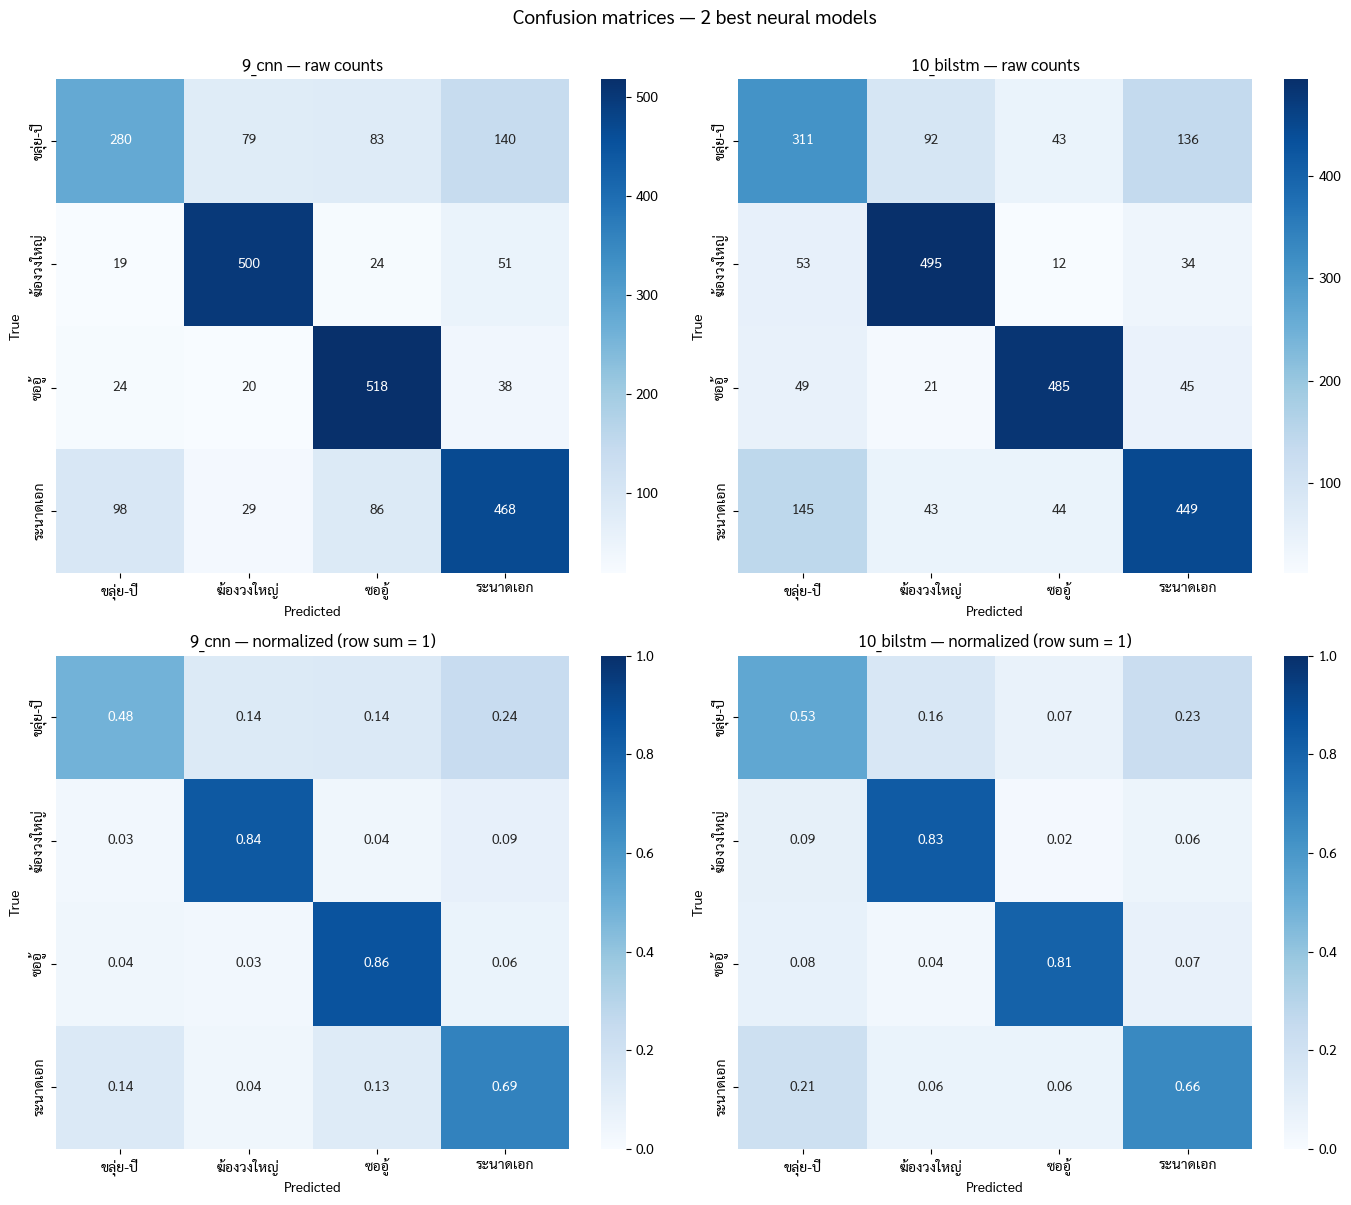


Recall per class — เทียบ neural vs shallow:


,6_svm_bigram (best shallow),9_cnn,10_bilstm,Δ best_neural - shallow
ขลุ่ย-ปี่,0.500,0.481,0.534,0.034
ฆ้องวงใหญ่,0.838,0.842,0.833,0.004
ซออู้,0.845,0.863,0.808,0.018
ระนาดเอก,0.639,0.687,0.659,0.048


In [25]:
# 2 best neural — tied ระหว่าง 9_cnn และ 10_bilstm (ตัวเลขแทบเท่ากัน)
# Accuracy ต่าง 0.0003, macro-F1 ต่าง 0.005 — น้อยกว่า std

print("=" * 70)
print("BEST NEURAL MODELS — tied ระหว่าง 9_cnn และ 10_bilstm")
print("=" * 70)

best_compare = neural_summary.loc[['9_cnn', '10_bilstm'],
                                    ['acc_mean', 'acc_std', 'f1_mean', 'f1_std', 'avg_epochs']]
display(best_compare.round(4))

print("\nหมายเหตุ: dataset นี้ balanced (ratio 1.17) — accuracy และ macro-F1")
print("ให้ผลใกล้กันมาก ตัวเลขทั้งคู่ใกล้กันจน 'best' ตัดสินยาก:")
print()
print("  - Accuracy:   9_cnn   ดีกว่าเล็กน้อย (+0.0003)")
print("  - Macro-F1:   10_bilstm ดีกว่า (+0.005) — สะท้อน per-class fairness")
print("  - Std:        10_bilstm เสถียรกว่า (0.079 vs 0.086)")
print("  - Params:     9_cnn เล็กกว่า (350K vs 663K)")
print("  - Train time: 9_cnn เร็วกว่า (39s vs 104s)")
print()
print("สรุป: 2 model ทำงานเทียบเท่ากัน — เลือกตาม trade-off ที่ project ต้องการ")
print("ภาพข้างล่างแสดงทั้งคู่เพื่อเปรียบเทียบ confusion pattern")

# Plot confusion 2x2 — 2 models × 2 views
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, model_name in enumerate(['9_cnn', '10_bilstm']):
    conf = neural_confusion[model_name]
    conf_norm = conf / conf.sum(axis=1, keepdims=True)

    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
                xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[0, col])
    axes[0, col].set_title(f'{model_name} — raw counts')
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('True')

    sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[1, col])
    axes[1, col].set_title(f'{model_name} — normalized (row sum = 1)')
    axes[1, col].set_xlabel('Predicted')
    axes[1, col].set_ylabel('True')

plt.suptitle('Confusion matrices — 2 best neural models', fontsize=14, y=1.00)
plt.tight_layout()
save_fig('confusion_best_neural')
plt.show()

# ตารางเทียบ recall + เทียบกับ best shallow จาก notebook 02
print("\nRecall per class — เทียบ neural vs shallow:")
recall_cnn = (neural_confusion['9_cnn'].diagonal() / neural_confusion['9_cnn'].sum(axis=1)).round(3)
recall_bilstm = (neural_confusion['10_bilstm'].diagonal() / neural_confusion['10_bilstm'].sum(axis=1)).round(3)
recall_shallow = np.array([0.500, 0.838, 0.845, 0.639])

compare = pd.DataFrame({
    '6_svm_bigram (best shallow)': recall_shallow,
    '9_cnn':                      recall_cnn,
    '10_bilstm':                  recall_bilstm,
    'Δ best_neural - shallow':    (np.maximum(recall_cnn, recall_bilstm) - recall_shallow).round(3),
}, index=INSTRUMENTS)
display(compare)